<a href="https://colab.research.google.com/github/rhonaeloisa/HEAKACORO/blob/main/revisedDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BIG DATA PROJECT**

Title: The "Risk-Ratio" Effect: Predictive Modeling of Workplace Incidents and Classification of Industry Risk Levels

Objectives:
1. To develop a predictive regression model that estimates the expected number of workplace incidents using historical data.

2. To develop a classification model that categorizes industries according to their level of workplace risk based on factors such as reported injury counts.

# **[PHASE 1] IMPORT LIBRARY & READ DATASET**

In [ ]:
from os import defpath
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
spark = SparkSession.builder.appName("InjuryData").getOrCreate()

df = spark.read.csv("/content/ITA_OSHA_Combined.csv",
                          header=True, inferSchema=True)
# Show the schema Spark inferred
#df.printSchema()

In [ ]:
df.count()

In [ ]:
df.show()

+---+--------------------+--------------------+----+--------------------+--------------+-----+--------+----------+--------------------+------------------------+------------------+---------------------+------------+----------------+----------------+-----------------+---------------+---------------+--------------+----------------+----------------------------+--------------------+------------------+---------------------+----------------+------------------+----+---------------+-----------------+--------------------+--------------------+------+
| id|        company_name|  establishment_name| ein|      street_address|          city|state|zip_code|naics_code|industry_description|annual_average_employees|total_hours_worked|no_injuries_illnesses|total_deaths|total_dafw_cases|total_djtr_cases|total_other_cases|total_dafw_days|total_djtr_days|total_injuries|total_poisonings|total_respiratory_conditions|total_skin_disorders|total_hearing_loss|total_other_illnesses|establishment_id|establishment_ty

# **[PHASE 2] DIAGNOSTIC**

**Filter Columns**

In [ ]:
df_filtered = df.select(
    "naics_code",
    "industry_description",
    "total_hours_worked",
    "no_injuries_illnesses",
    "total_injuries",
    "size",
    "establishment_type",
    "year_filing_for"
)

# Count total rows
total_rows = df_filtered.count()
print(total_rows)


1635695


In [ ]:
df_plot = df_filtered.select("total_hours_worked", "total_injuries", "no_injuries_illnesses").sample(0.1).toPandas()

plt.figure(figsize=(15, 5))

# Plot 1: Total Injuries
plt.subplot(1, 3, 1)
sns.boxplot(y=df_plot['total_injuries'], color='salmon')
plt.title('Outliers: Total Injuries')

# Plot 2: Total Hours Worked
plt.subplot(1, 3, 2)
sns.boxplot(y=df_plot['total_hours_worked'])
plt.title('Outliers: Total Hours Worked')

# Plot 3: No Injuries/Illnesses
plt.subplot(1, 3, 3)
sns.boxplot(y=df_plot['no_injuries_illnesses'], color='lightblue')
plt.title('Outliers: No Injuries/Illnesses')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

**Find Missing Values**

In [ ]:
# Compute percentage of missing values per column
missing_percent = df_filtered.select([
    (F.count(F.when(F.col(c).isNull(), c)) / total_rows * 100).alias(c)
    for c in df_filtered.columns
])

missing_percent.show()

**Find Duplicates**

In [ ]:
# Count duplicate rows in PySpark
duplicate_rows = (
    df_filtered
    .groupBy(df_filtered.columns)
    .count()
    .filter(F.col("count") > 1)
    .select((F.sum("count") - F.count("count")).alias("duplicate_rows"))
    .collect()[0][0]
)

print("Number of duplicate rows:", duplicate_rows)

**Identify Garbage Values**

In [ ]:
# Identify string (object-like) columns in PySpark
string_cols = [c for c, t in df_filtered.dtypes if t == "string"]

# Loop through each string column and print value counts
for c in string_cols:
    print(f"Value counts for column: {c}")
    df_filtered.groupBy(c).count().orderBy(F.desc("count")).show()
    print("***" * 10)

# **[PHASE 3] DATA CLEANING WITH VISUALIZATION (BEFORE & AFTER)**



Remove string values in column size and establishment type


In [ ]:
from pyspark.sql import functions as F

# Keep only rows where size is one of the specified string values

df_filtered_size = df_filtered.filter(
    F.col("size").isin("1", "2", "3", "1.0", "2.0", "3.0")
)

df_counts = (
    df_filtered_size
    .filter(F.col("size").isin("1", "2", "3", "1.0"))
    .groupBy("size")
    .count()
)

df_counts.show()

+----+-------+
|size|  count|
+----+-------+
| 1.0|     41|
|   3| 188227|
|   1| 255738|
|   2|1191109|
+----+-------+



**EDA FOR SIZE COLUMN**

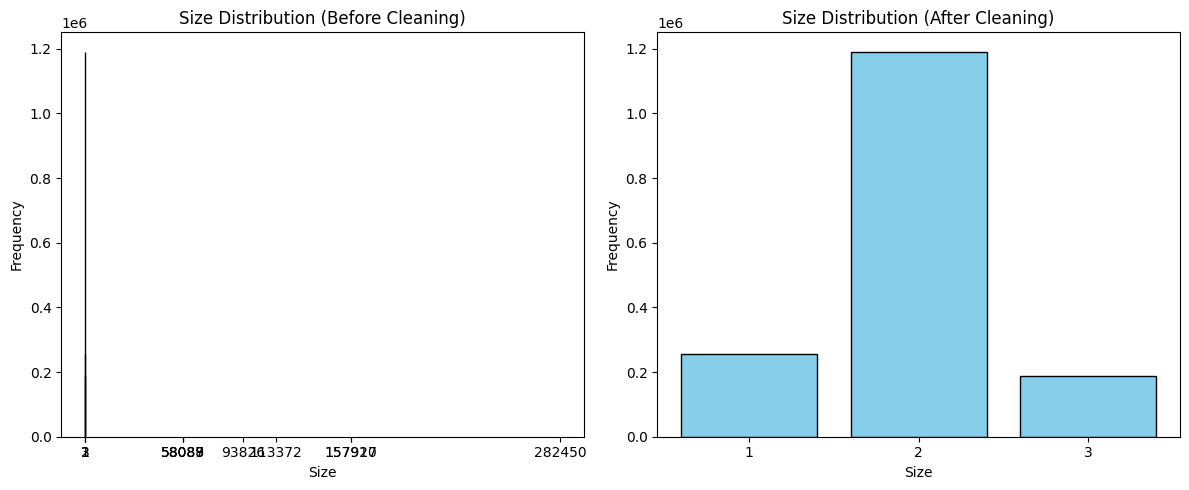

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Convert Spark DataFrames to Pandas
pdf_before = df_filtered.select("size").toPandas()
pdf_after = df_filtered_size.select("size").toPandas()

# Cast both to numeric (strings like "1.0" → 1.0, invalid → NaN)
pdf_before["size"] = pd.to_numeric(pdf_before["size"], errors="coerce")
pdf_after["size"] = pd.to_numeric(pdf_after["size"], errors="coerce")

# Cast 'after' to int for cleaner bins
pdf_after["size"] = pdf_after["size"].astype(int)

# Count frequencies
counts_before = pdf_before["size"].value_counts().sort_index()
counts_after = pdf_after["size"].value_counts().sort_index()

# Create subplots: bar graphs before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar graph BEFORE cleaning
axes[0].bar(counts_before.index, counts_before.values, color="lightcoral", edgecolor="black")
axes[0].set_title("Size Distribution (Before Cleaning)")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(counts_before.index)  # show only actual integer values

# Bar graph AFTER cleaning
axes[1].bar(counts_after.index, counts_after.values, color="skyblue", edgecolor="black")
axes[1].set_title("Size Distribution (After Cleaning)")
axes[1].set_xlabel("Size")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(counts_after.index)

plt.tight_layout()
plt.show()


In [ ]:
df_filtered_establishment = df_filtered_size.filter(
    F.col("establishment_type").isin("1", "2", "3", "1.0", "2.0", "3.0")
)

df_counts2 = (
    df_filtered_establishment
    .filter(F.col("establishment_type").isin("1", "2", "3", "1.0", "2.0", "3.0"))
    .groupBy("establishment_type")
    .count()
)

df_counts2.show()

+------------------+-------+
|establishment_type|  count|
+------------------+-------+
|               1.0|1165100|
|                 3|   8298|
|               2.0|  28664|
|                 1| 274710|
|               3.0|  36076|
|                 2|   4483|
+------------------+-------+



**EDA FOR** **ESTABLISHMENT_TYPE**

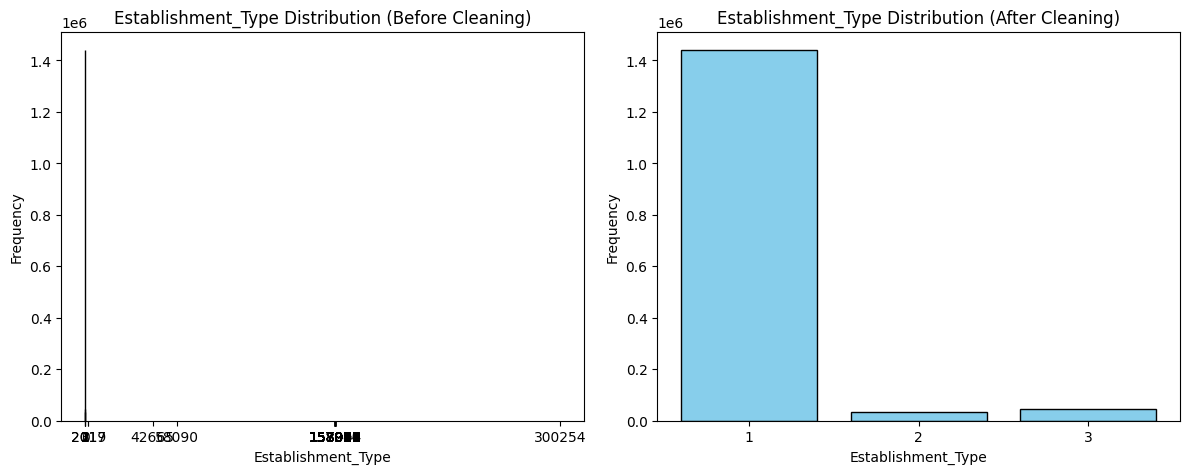

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Convert Spark DataFrames to Pandas
pdf_before = df_filtered.select("establishment_type").toPandas()
pdf_after = df_filtered_establishment.select("establishment_type").toPandas()

# Cast both to numeric (strings like "1.0" → 1.0, invalid → NaN)
pdf_before["establishment_type"] = pd.to_numeric(pdf_before["establishment_type"], errors="coerce")
pdf_after["establishment_type"] = pd.to_numeric(pdf_after["establishment_type"], errors="coerce")

# Drop NaN values
#pdf_before = pdf_before.dropna()
#pdf_after = pdf_after.dropna()

# Cast 'after' to int for cleaner bins
pdf_after["establishment_type"] = pdf_after["establishment_type"].astype(int)

# Count frequencies
counts_before = pdf_before["establishment_type"].value_counts().sort_index()
counts_after = pdf_after["establishment_type"].value_counts().sort_index()

# Create subplots: bar graphs before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar graph BEFORE cleaning
axes[0].bar(counts_before.index, counts_before.values, color="lightcoral", edgecolor="black")
axes[0].set_title("Establishment_Type Distribution (Before Cleaning)")
axes[0].set_xlabel("Establishment_Type")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(counts_before.index)  # show only actual integer values

# Bar graph AFTER cleaning
axes[1].bar(counts_after.index, counts_after.values, color="skyblue", edgecolor="black")
axes[1].set_title("Establishment_Type Distribution (After Cleaning)")
axes[1].set_xlabel("Establishment_Type")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(counts_after.index)

plt.tight_layout()
plt.show()


**String Normalization**

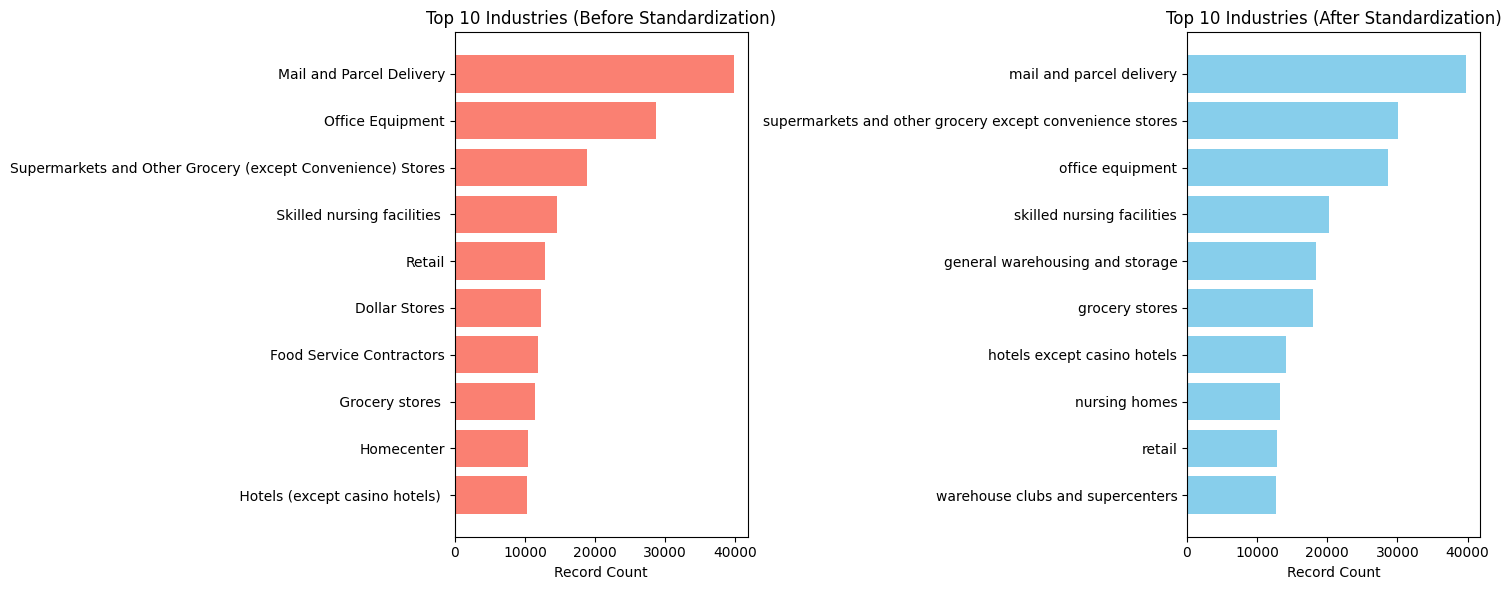

+---------------------------------------------------+---------------------------------------------------+
|industry_description                               |industry_CLEANED                                   |
+---------------------------------------------------+---------------------------------------------------+
|Photography services, portrait (e.g., still, video)|photography services portrait eg still video       |
|Water supply systems                               |water supply systems                               |
|Switchgear and switchgear accessories manufacturing|switchgear and switchgear accessories manufacturing|
|Kitchen cabinets and counters, constructed on site |kitchen cabinets and counters constructed on site  |
|Holding companies (except bank, managing)          |holding companies except bank managing             |
|Aerospace Products & Parts Manfacturing            |aerospace products  parts manfacturing             |
|Monuments and grave markers merchant wholesal

In [ ]:
df_SNorm = df_filtered.withColumn("industry_CLEANED",
    F.trim(F.regexp_replace(F.lower(F.col("industry_description")), "[^a-zA-Z0-9\\s]", ""))
)

# EDA DATA GATHERING
before_pd = df_filtered.filter(F.col("industry_description").isNotNull()) \
    .groupBy("industry_description").count().orderBy(F.desc("count")).limit(10).toPandas()

after_pd = df_SNorm.filter(F.col("industry_CLEANED").isNotNull()) \
    .groupBy("industry_CLEANED").count().orderBy(F.desc("count")).limit(10).toPandas()

# VISUALIZATION
plt.figure(figsize=(15, 6))

# Subplot 1: Before Cleaning
plt.subplot(1, 2, 1)
plt.barh(before_pd['industry_description'], before_pd['count'], color='salmon')
plt.title('Top 10 Industries (Before Standardization)')
plt.gca().invert_yaxis()
plt.xlabel('Record Count')

# Subplot 2: After Cleaning
plt.subplot(1, 2, 2)
plt.barh(after_pd['industry_CLEANED'], after_pd['count'], color='skyblue')
plt.title('Top 10 Industries (After Standardization)')
plt.gca().invert_yaxis()
plt.xlabel('Record Count')

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY
df_SNorm.select("industry_description", "industry_CLEANED").distinct().show(10, truncate=False)
original_unique = df_filtered.select("industry_description").distinct().count()
new_unique = df_SNorm.select("industry_CLEANED").distinct().count()

print(f"\n\n\n--- EDA SUMMARY ---")
print(f"Unique Categories (BEFORE): {original_unique}")
print(f"Unique Categories (AFTER): {new_unique}")
print(f"Reduction: {original_unique - new_unique} duplicates merged.")

**Schema Validation**

In [ ]:
df_filtered.show(200)
df_filtered.printSchema()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    238220|Heating, ventilat...|          579688.0|                  1.0|             6|   3|               1.0|         2016.0|
|    336612|Pleasure boats ma...|          501578.0|                  1.0|            13|   3|               1.0|         2016.0|
|    336370|Motor vehicle met...|          619945.0|                  1.0|            18|   3|               1.0|         2016.0|
|    336612|Pleasure boats ma...|           75794.0|                  1.0|             1|   2|               1.0|         2016.0|
|    336612|Pleasure boats ma...|          114734.0|                  1.0|             6| 

In [ ]:
df_SValid = df_SNorm.select(
    F.expr("try_cast(naics_code as double)").cast("int").alias("naics_code"),
    F.col("industry_CLEANED").alias("industry_description"),
    F.expr("try_cast(total_hours_worked as double)").alias("total_hours_worked"),
    F.expr("try_cast(no_injuries_illnesses as double)").cast("int").alias("no_injuries_illnesses"),
    F.expr("try_cast(total_injuries as double)").cast("int").alias("total_injuries"),
    F.expr("try_cast(size as double)").cast("int").alias("size"),
    F.expr("try_cast(establishment_type as double)").cast("int").alias("establishment_type"),
    F.expr("try_cast(year_filing_for as double)").cast("int").alias("year_filing_for")
)

df_SValid.printSchema()
df_SValid.show(200)

root
 |-- naics_code: integer (nullable = true)
 |-- industry_description: string (nullable = true)
 |-- total_hours_worked: double (nullable = true)
 |-- no_injuries_illnesses: integer (nullable = true)
 |-- total_injuries: integer (nullable = true)
 |-- size: integer (nullable = true)
 |-- establishment_type: integer (nullable = true)
 |-- year_filing_for: integer (nullable = true)

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    238220|heating ventilati...|          579688.0|                    1|             6|   3|                 1|           2016|
|    336612|pleasure boats ma...|          501578.0|                    1|            13|   

**Duplicates Treatment**

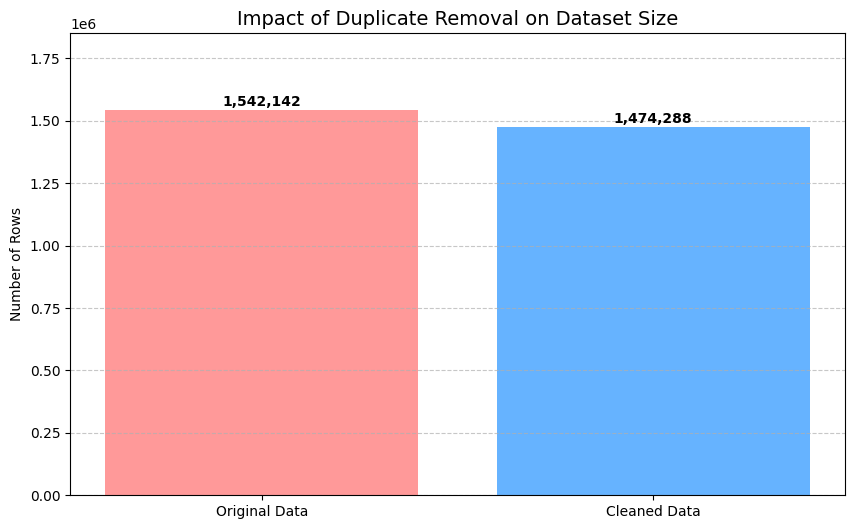



--- DUPLICATE CHECK REPORT ---
Initial Rows: 1542142
Current Rows: 1474288
Removed Duplicates: 67854


In [ ]:
initial_count = df_filtered.count()
df_DDup = df_SValid.dropDuplicates()
df_final_count = df_DDup.count()


# 2. DATA PREPARATION FOR PLOTTING
eda_data = pd.DataFrame({
   'Stage': ['Original Data', 'Cleaned Data'],
   'Row Count': [initial_count, df_final_count]
})


# 3. VISUALIZATION
plt.figure(figsize=(10, 6))


# Bar Chart: Comparison of Row Counts
bars = plt.bar(eda_data['Stage'], eda_data['Row Count'], color=['#ff9999','#66b3ff'])


# Add labels on top of bars
for bar in bars:
   yval = bar.get_height()
   plt.text(bar.get_x() + bar.get_width()/2, yval + 5000, f'{int(yval):,}', ha='center', va='bottom', fontweight='bold')


plt.title('Impact of Duplicate Removal on Dataset Size', fontsize=14)
plt.ylabel('Number of Rows')
plt.ylim(0, initial_count * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()


print(f"\n\n--- DUPLICATE CHECK REPORT ---")
print(f"Initial Rows: {initial_count}")
print(f"Current Rows: {df_final_count}")
print(f"Removed Duplicates: {initial_count - df_final_count}")

**Missing Value Treatment**

In [ ]:
df_DDup.toPandas().head()

,naics_code,industry_description,total_hours_worked,no_injuries_illnesses,total_injuries,size,establishment_type,year_filing_for
0,332321.0,doors metal manufacturing,5437070.0,1.0,4.0,3.0,1.0,2016.0
1,611310.0,colleges universities and professional schools,304226.0,2.0,0.0,2.0,2.0,2016.0
2,237110.0,construction management water and sewer line,47290.0,1.0,2.0,2.0,1.0,2016.0
3,623110.0,convalescent homes or convalescent hospitals e...,71996.0,1.0,5.0,2.0,1.0,2016.0
4,334511.0,search and detection systems and instruments m...,254519.0,1.0,3.0,2.0,1.0,2016.0


In [ ]:
import pandas as pd
from pyspark.sql.functions import col, sum, count, when

df_DDup.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_DDup.columns
]).show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|         2|              102473|                25|                    6|             5|  28|             98190|             25|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+



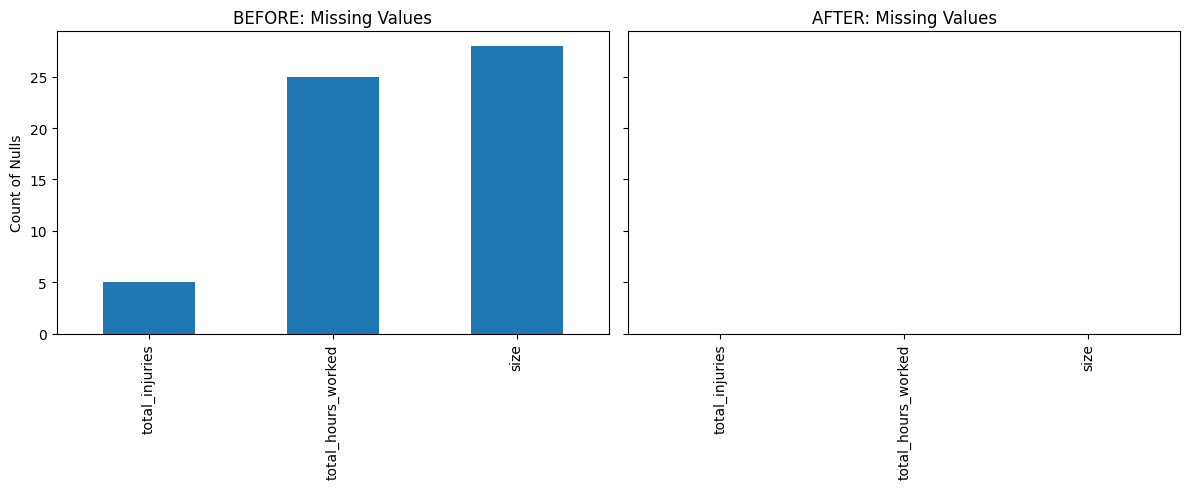

In [ ]:
#df_cleanedNull_1
#Clean total injuries and total hours work null

df_cleanedNull_1 = df_DDup.dropna(subset=["total_injuries", "total_hours_worked", "size"])

# func to get nulls for specifi columns
def get_null_counts(df, columns):
    return df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in columns]).toPandas()

cols_to_check = ["total_injuries", "total_hours_worked", "size"]

nulls_before = get_null_counts(df_SValid, cols_to_check).iloc[0]
nulls_after = get_null_counts(df_cleanedNull_1, cols_to_check).iloc[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

nulls_before.plot(kind='bar', ax=ax[0])
ax[0].set_title("BEFORE: Missing Values")
ax[0].set_ylabel("Count of Nulls")

nulls_after.plot(kind='bar', ax=ax[1])
ax[1].set_title("AFTER: Missing Values")

plt.tight_layout()
plt.show()

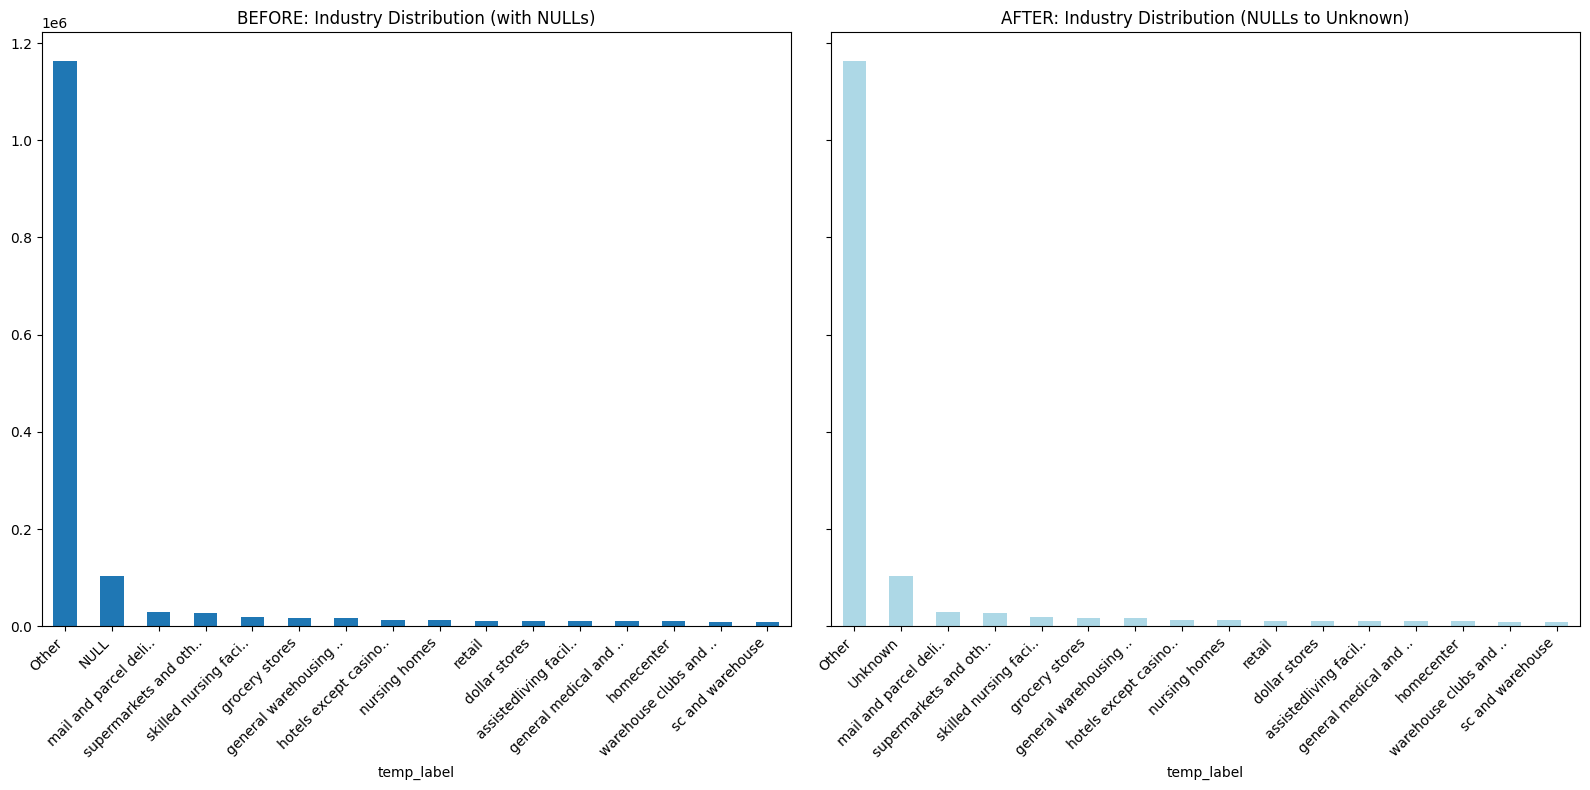

In [ ]:
#df_cleanedNull_2
#Clean industry description null

df_cleanedNull_2 = df_cleanedNull_1.fillna({
    "industry_description": "Unknown"
})

#keep only top 10 industry so the graph won't be clustered
top_industries = df_cleanedNull_1.groupBy("industry_description") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(15) \
    .select("industry_description") \
    .rdd.flatMap(lambda x: x).collect()

#put other industries not included to top 10 to other (temporary)
before_pd = df_cleanedNull_1.withColumn(
    "temp_label",
    F.when(F.col("industry_description").isin(top_industries), F.col("industry_description"))
    .when(F.col("industry_description").isNull(), "NULL")
    .otherwise("Other")
).groupBy("temp_label").count().toPandas()


after_pd = df_cleanedNull_2.withColumn(
    "temp_label",
    F.when(F.col("industry_description").isin(top_industries), F.col("industry_description"))
    .when(F.col("industry_description") == "Unknown", "Unknown")
    .otherwise("Other")
).groupBy("temp_label").count().toPandas()

#trim text so label won't be too long
before_pd['temp_label'] = before_pd['temp_label'].apply(lambda x: (x[:20] + '..') if len(x) > 20 else x)
after_pd['temp_label'] = after_pd['temp_label'].apply(lambda x: (x[:20] + '..') if len(x) > 20 else x)


fig, ax = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# BEFORE
before_pd.sort_values('count', ascending=False).plot(
    kind='bar', x='temp_label', y='count', ax=ax[0], legend=False
)
ax[0].set_title("BEFORE: Industry Distribution (with NULLs)")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

# AFTER
after_pd.sort_values('count', ascending=False).plot(
    kind='bar', x='temp_label', y='count', ax=ax[1], color='lightblue', legend=False
)
ax[1].set_title("AFTER: Industry Distribution (NULLs to Unknown)")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

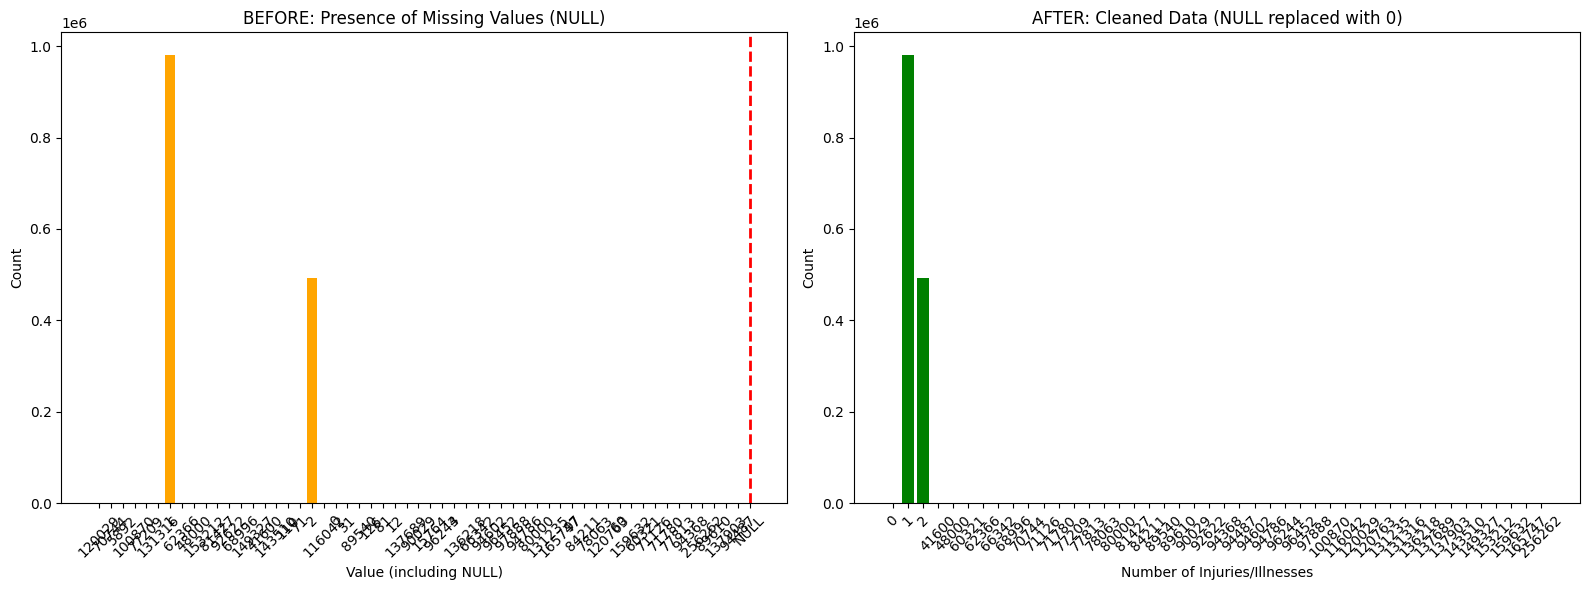

In [ ]:
#df_cleanedNull_3
#Clean no_injuries_illnesses null

df_cleanedNull_3 = df_cleanedNull_2.fillna({
    "no_injuries_illnesses": 0
})

before_non_nulls_pd = df_SValid.filter(
    F.col("no_injuries_illnesses").isNotNull()
).groupBy("no_injuries_illnesses").count().toPandas()

before_null_count = df_SValid.filter(
    F.col("no_injuries_illnesses").isNull()
).count()

before_non_nulls_pd["val"] = before_non_nulls_pd["no_injuries_illnesses"].astype(str)

before_plot = before_non_nulls_pd[["val", "count"]].copy()

# explicitly add NULL category if exists
if before_null_count > 0:
    before_plot = pd.concat([
        before_plot,
        pd.DataFrame([{"val": "NULL", "count": before_null_count}])
    ], ignore_index=True)

after_pd = df_cleanedNull_3.select("no_injuries_illnesses").toPandas()

after_counts = after_pd["no_injuries_illnesses"].value_counts().sort_index()

#plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

#before
ax[0].bar(before_plot["val"], before_plot["count"], color="orange")
ax[0].set_title("BEFORE: Presence of Missing Values (NULL)")
ax[0].set_xlabel("Value (including NULL)")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=45)

#highlight NULL visually
if "NULL" in before_plot["val"].values:
    ax[0].axvline(
        x=list(before_plot["val"]).index("NULL"),
        color="red",
        linestyle="--",
        linewidth=2
    )

#after
ax[1].bar(after_counts.index.astype(str), after_counts.values, color="green")
ax[1].set_title("AFTER: Cleaned Data (NULL replaced with 0)")
ax[1].set_xlabel("Number of Injuries/Illnesses")
ax[1].set_ylabel("Count")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#df_cleanedNull_4
#Clean establishment type null

df_cleanedNull_4 = df_cleanedNull_3.fillna({
    "establishment_type": -1
})

In [ ]:
#df_cleanedNull_final
#Clean year filing for null

mode_year = df_cleanedNull_4.groupBy("year_filing_for").count().orderBy("count", ascending=False).first()[0]

df_cleanedNull_final = df_cleanedNull_4.fillna({
    "year_filing_for": mode_year
})

In [ ]:
df_cleanedNull_final.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_cleanedNull_final.columns
]).show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|         0|                   0|                 0|                    0|             0|   0|                 0|              0|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+



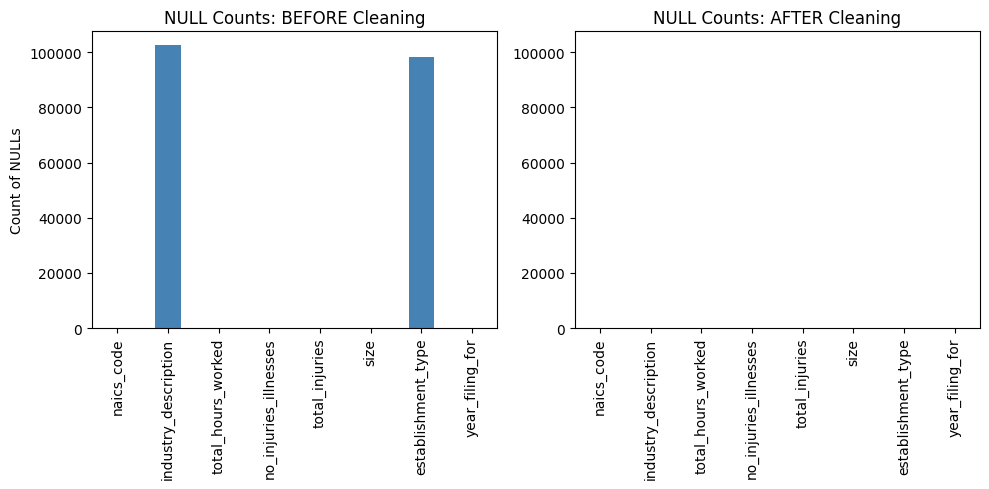

In [ ]:
before = df_DDup.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_DDup.columns
]).toPandas().T

after = df_cleanedNull_final.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_cleanedNull_final.columns
]).toPandas().T

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Before Cleaning of Missing Values
before.plot(kind="bar", ax=axes[0], color='steelblue', legend=False)
axes[0].set_title("NULL Counts: BEFORE Cleaning")
axes[0].set_ylabel("Count of NULLs")

# After Cleaning of Missing Values
after.plot(kind="bar", ax=axes[1], color='orange', legend=False)
axes[1].set_title("NULL Counts: AFTER Cleaning")
axes[1].set_ylim(axes[0].get_ylim())

plt.tight_layout()
plt.show()

In [ ]:
total_rows = df_cleanedNull_final.count()
print(total_rows)

1474240


In [ ]:
df_cleanedNull_final.show(200)

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    332321|doors metal manuf...|         5437070.0|                    1|             4|   3|                 1|           2016|
|    611310|colleges universi...|          304226.0|                    2|             0|   2|                 2|           2016|
|    237110|construction mana...|           47290.0|                    1|             2|   2|                 1|           2016|
|    623110|convalescent home...|           71996.0|                    1|             5|   2|                 1|           2016|
|    334511|search and detect...|          254519.0|                    1|             3| 

**Garbage Value Detection**

In [ ]:
df_initial_for_garbage_removal = df_cleanedNull_final

garbage_rows_count = df_initial_for_garbage_removal.filter(
    (F.col("total_hours_worked") <= 0) | F.col("total_hours_worked").isNull()
).count()

print(f"Garbage rows (total_hours_worked <= 0 or null): {garbage_rows_count}")

#filter out the garbage rows and assign to df_cleaned
df_cleaned = df_initial_for_garbage_removal.filter(
    (F.col("total_hours_worked") > 0) & F.col("total_hours_worked").isNotNull()
)

print("Rows BEFORE garbage removal:", df_initial_for_garbage_removal.count())
print("Rows AFTER garbage removal:", df_cleaned.count())

Garbage rows (total_hours_worked <= 0 or null): 461
Rows BEFORE garbage removal: 1474240
Rows AFTER garbage removal: 1473779


**Outlier Treatments**

Outlier Capping for 'total_hours_worked'
Calculated Q1: 41376.0, Q3: 182439.0, IQR: 141063.0
Lower Bound for Capping: -170218.5
Upper Bound for Capping: 394033.5


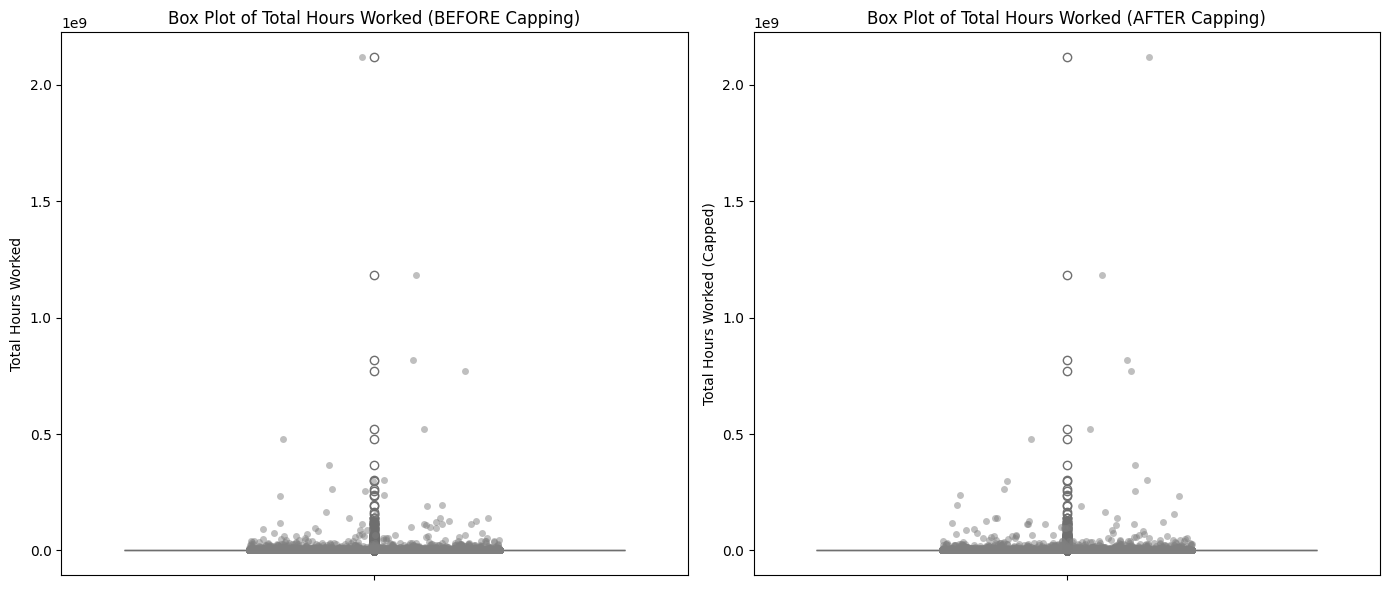

In [139]:
print("Outlier Capping for 'total_hours_worked'")

# Get 'before' data for visualization (before capping)
pdf_before_capping = df_cleanedNull_final.select("total_hours_worked").sample(False, 0.1, seed=42).toPandas()

#Q1, Q3, and IQR for total_hours_worked
Q1 = df_cleaned.approxQuantile("total_hours_worked", [0.25], 0.05)[0]
Q3 = df_cleaned.approxQuantile("total_hours_worked", [0.75], 0.05)[0]
IQR = Q3 - Q1

#lower and upper bounds for outlier capping
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Calculated Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound for Capping: {lower_bound}")
print(f"Upper Bound for Capping: {upper_bound}")

#Winsorization (capping) to total_hours_worked
df_cleaned = df_cleaned.withColumn(
    "total_hours_worked",
    F.when(F.col("total_hours_worked") < lower_bound, lower_bound)
     .when(F.col("total_hours_worked") > upper_bound, upper_bound)
     .otherwise(F.col("total_hours_worked"))
)

pdf_after_capping = df_cleanedNull_final.select("total_hours_worked").sample(False, 0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#before capping
sns.boxplot(y=pdf_before_capping['total_hours_worked'], ax=axes[0], color='lightcoral')
sns.stripplot(y=pdf_before_capping['total_hours_worked'], ax=axes[0], color='grey', jitter=0.2, alpha=0.5)
axes[0].set_title('Box Plot of Total Hours Worked (BEFORE Capping)')
axes[0].set_ylabel('Total Hours Worked')

#after capping
sns.boxplot(y=pdf_after_capping['total_hours_worked'], ax=axes[1], color='skyblue')
sns.stripplot(y=pdf_after_capping['total_hours_worked'], ax=axes[1], color='grey', jitter=0.2, alpha=0.5)
axes[1].set_title('Box Plot of Total Hours Worked (AFTER Capping)')
axes[1].set_ylabel('Total Hours Worked (Capped)')

plt.tight_layout()
plt.show()

**SAVE TO PARQUET FILE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned.write.mode("overwrite").parquet(save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **[PHASE 3] EDA FOR VALIDATION**

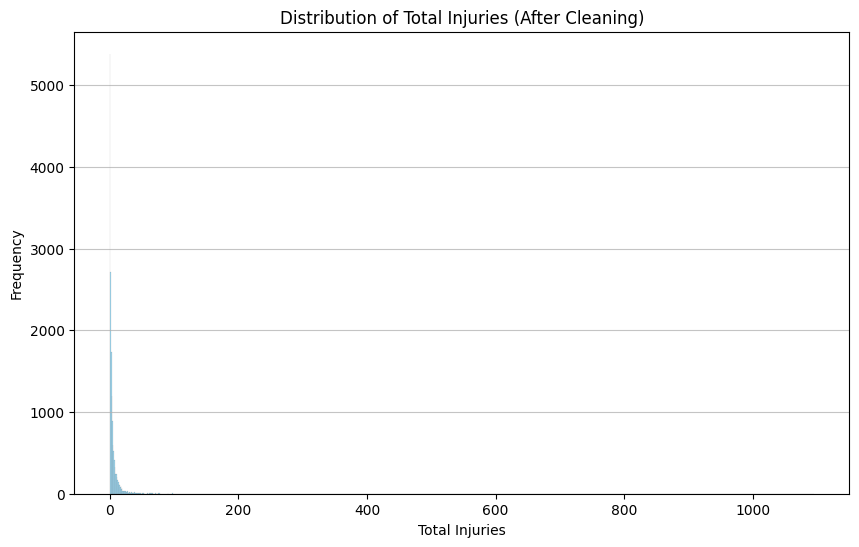

In [ ]:
viz_df_cleaned = df_cleanedNull_final.select("total_injuries").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(viz_df_cleaned['total_injuries'], bins=range(int(viz_df_cleaned['total_injuries'].min()),
int(viz_df_cleaned['total_injuries'].max()) + 2), kde=False, color='skyblue', edgecolor='black')

plt.title('Distribution of Total Injuries (After Cleaning)')
plt.xlabel('Total Injuries')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

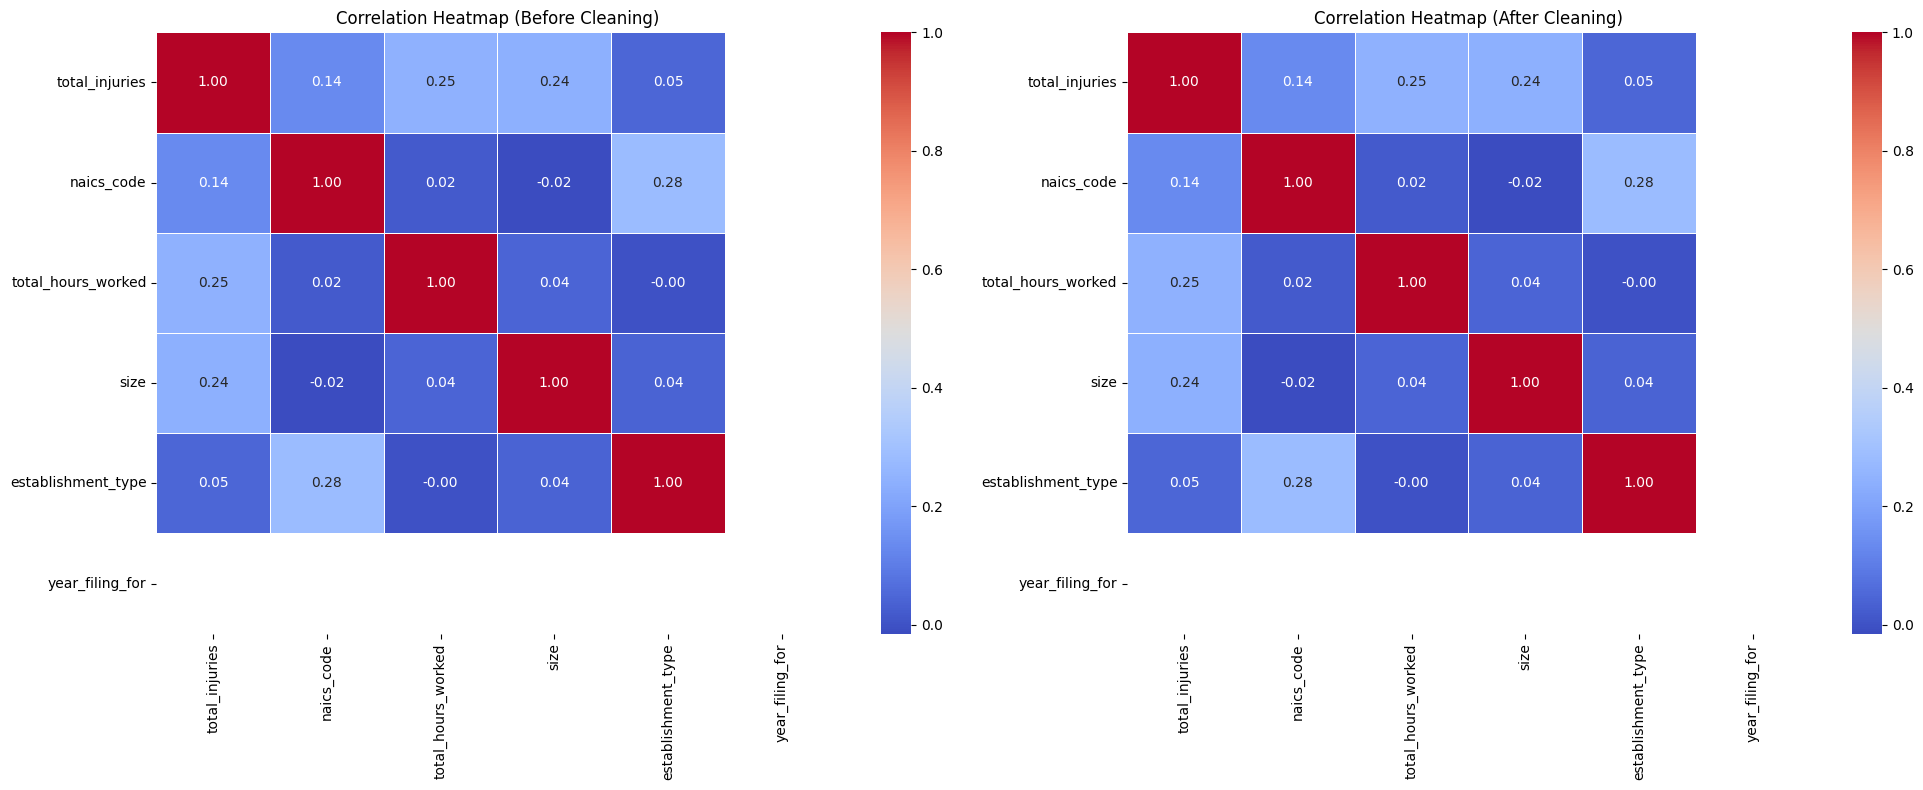

In [ ]:
from pyspark.sql.types import DoubleType

numerical_cols = [
    "total_injuries",
    "naics_code",
    "total_hours_worked",
    "size",
    "establishment_type",
    "year_filing_for"
]

#Before Cleaning Correlation (using df_SValid)
pdf_numerical_before = df_SValid.select(numerical_cols).limit(10000).toPandas()
corr_matrix_before = pdf_numerical_before.corr()

#After Cleaning Correlation (using df_cleaned)
pdf_numerical_after = df_cleanedNull_final.select(numerical_cols).limit(10000).toPandas()
corr_matrix_after = pdf_numerical_after.corr()

#plotting heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#Before Cleaning
sns.heatmap(corr_matrix_before, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap (Before Cleaning)')

#After Cleaning
sns.heatmap(corr_matrix_after, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap (After Cleaning)')

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned.printSchema()

**[4] VISUALIZATION BEFORE CLEANING**


In [ ]:
#descriptive statistics
df_SValid.describe().show()

In [ ]:
df_SValid.toPandas().head()

In [ ]:
#scatter plot to understand the relationship (for numerical data)
viz_df = df_SValid.sample(False, 0.1).toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=viz_df, x="total_hours_worked", y="total_injuries", alpha=0.5, color='teal')
plt.title("Relationship Between Total Hours Worked and Injury Count")
plt.xlabel("Total Hours Worked")
plt.ylabel("Total Injuries")
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
# Sample from df_cleaned for visualization, ensuring viz_df is defined
viz_df = df_cleaned.sample(False, 0.1, seed=42).toPandas()

# Using estimator=sum to show the total volume of injuries per year
sns.barplot(data=viz_df, x="year_filing_for", y="total_injuries", estimator=sum, errorbar=None, palette="viridis")
plt.title("Total Injuries per Filing Year")
plt.xlabel("Year")
plt.ylabel("Sum of Total Injuries")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
# Sample from df_cleaned for visualization, ensuring viz_df is defined
viz_df = df_cleaned.sample(False, 0.1, seed=42).toPandas()
sns.boxplot(data=viz_df, x="size", y="total_injuries", palette="Set2")
plt.title("Injury Distribution Across Different Company Sizes")
plt.xlabel("Company Size (Categorical)")
plt.ylabel("Total Injuries")

# Limiting Y-axis if outliers make the boxes too small to see
plt.ylim(0, viz_df['total_injuries'].quantile(0.95))
plt.show()

# **[PHASE 4] FEATURE ENGINEERING**

STRING INDEXER

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexer = StringIndexer(
    inputCol="industry_description",
    outputCol="industry_description_index",
    handleInvalid="keep"
)

encoder = OneHotEncoder(
    inputCol="industry_description_index",
    outputCol="industry_description_vec"
)

VECTOR ASSEMBLY

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "naics_code",
        "total_hours_worked",
        "no_injuries_illnesses",
        "total_injuries",
        "size",
        "establishment_type",
        "year_filing_for",
        "industry_description_vec"
    ],
    outputCol="features"
)

# **[PHASE 5] APPLYING ALGORITHMS**

**Objective 1 - Prediction**



**Objective 2 - Classification**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
